In [14]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage, AnyMessage
from langchain_groq import ChatGroq
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from typing import TypedDict, Literal, Annotated

In [ ]:
from dotenv import load_dotenv
import os
load_dotenv()

In [ ]:
llm = ChatGroq(model='llama-3.3-70b-versatile',
               api_key=os.getenv('GROQ_API_KEY')) #type: ignore

In [15]:
class RouteState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    route: Literal['code', 'writing', 'general']

In [16]:
def code_agent(state: RouteState):
    messages = [SystemMessage(content='You are a helpful code assistant')] + state['messages']
    return {'messages': [llm.invoke(messages)]}

In [17]:
from langchain_core.messages import HumanMessage
output = code_agent({'messages': [HumanMessage(content='implemennt a function to generate fibonacci numbers')]})

In [19]:
def writer_agent(state: RouteState):
    messages = [SystemMessage(content="You are a professional writer. Write clearly, concisely, and engagingly.")] + \
        state['messages']
    return {'messages': llm.invoke(messages)}

In [20]:
def general_agent(state: RouteState):
    messages = [SystemMessage(content='You are a helpful assistant, specialized for common, general question. Do not answer question with deep knowledge')] + \
        state['messages']
    return {'messages': llm.invoke(messages)}

In [30]:
def router(state: RouteState):
    messages = [SystemMessage(content="Classify as 'code', 'writing' if not those 2 then 'general'. Output only the category")] + \
        state['messages']
    route = llm.invoke(messages).content
    return {'route': route}

In [31]:
def pick_route(state: RouteState) -> str:
    return state["route"] if state["route"] in ("code", "math") else "general"

In [ ]:
graph = StateGraph(RouteState)

graph.add_node('router', router)
graph.add_node('code', code_agent)
graph.add_node('writing', writer_agent)
graph.add_node('general', general_agent)

graph.set_entry_point('router')

graph.add_conditional_edges('router' , pick_route, {
    'code': 'code',
    'writing': 'writing',
    'general': 'general',
})

graph.add_edge('code', END)
graph.add_edge('writing', END)
graph.add_edge('general', END)

app = graph.compile()

In [33]:
from IPython.display import display, Image
def get_png_img(app):
    display(Image(app.get_graph().draw_mermaid_png()))

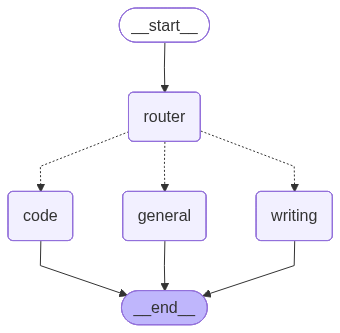

In [34]:
get_png_img(app)

In [35]:
app.invoke({'messages': 'Tell me a short story about Elon Musk'})

{'messages': [HumanMessage(content='Tell me a short story about Elon Musk', additional_kwargs={}, response_metadata={}, id='c5390968-e3e7-4c1b-a05d-8e388deed290'),
  AIMessage(content="Elon Musk was a young boy with big dreams. He loved reading and learning new things, especially about space and technology. As he grew older, his curiosity and passion only grew stronger.\n\nOne day, Elon decided to start his own company to make electric cars. People thought he was crazy, but he didn't give up. He worked hard and eventually created Tesla, a company that made beautiful and environmentally friendly cars.\n\nYears went by, and Elon's company became very successful. He then decided to pursue his other dream: going to space. He started another company called SpaceX, with the goal of taking people to the moon and even to Mars one day.\n\nElon's hard work and determination inspired many people around the world. He showed that with big dreams and a lot of effort, anything is possible. And who kn

In [37]:
app.invoke({'messages': 'who is the president of US in 2021'})

{'messages': [HumanMessage(content='who is the president of US in 2021', additional_kwargs={}, response_metadata={}, id='cae1444f-bb84-4b69-883f-ddcd23f03968'),
  AIMessage(content='The President of the United States in 2021 was Joe Biden. He took office on January 20, 2021.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 65, 'total_tokens': 92, 'completion_time': 0.068900176, 'completion_tokens_details': None, 'prompt_time': 0.00242198, 'prompt_tokens_details': None, 'queue_time': 0.16523133, 'total_time': 0.071322156}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6c71-4780-7e12-bdfa-dbf9216031a0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 65, 'output_tokens': 27, 'total_tokens': 92})],
 'route': 'general'}